# Recovery Prediction Model — DPD/Bounce Collections
### ETL → EDA → Feature Engineering → Model Training (XGBoost + Optuna) → Explainability (SHAP)

This notebook replaces the original Postgres-based data loader with an **ETL layer that reads
directly from `Reports-Last-6-Months.xlsx`** (the export you uploaded), since we don't have a live
DB connection here. Everything downstream (feature engineering, rolling time-series validation,
Optuna tuning, SHAP explainability, continuous learning) follows the same logic as the original
script, adapted to the columns that actually exist in this workbook.

**Workbook sheets used:**
| Sheet | Role |
|---|---|
| `Strategy Execution Log` | one row per execution → this is our modeling grain |
| `Dpd Cases` / `Bounce Cases` | case-level details, joined on `case_id` depending on `case_type` |
| `Strategies` | strategy metadata (journey_type, priority, customer_segment, ...) |
| `Branches` | branch → zone/region/type lookup |
| `Payments` | recovery amounts, aggregated per strategy |
| `Communication_logs` | contact attempts, aggregated per strategy |
| `Ptps` | promise-to-pay records, aggregated per strategy |
| `Agents` | agent roster (only 1 agent in this sample export) |


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    ConfusionMatrixDisplay, log_loss,
)
from xgboost import XGBClassifier
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

SOURCE_XLSX = "Reports-Last-6-Months.xlsx"
CHARTS_DIR = "model_artifacts/charts"
MODEL_OUTPUT_PATH = "model_artifacts/recovery_model.pkl"
PIPELINE_OUTPUT_PATH = "model_artifacts/preprocessing_pipeline.pkl"
LABEL_ENCODER_PATH = "model_artifacts/label_encoder.pkl"
os.makedirs(CHARTS_DIR, exist_ok=True)

CLASS_LABELS = [
    "Write Off",
    "High Risk",
    "Likely Recoverable",
    "Partially Recovered",
    "Fully Recovered",
]


## 1. ETL — Extract, Transform, Load

### 1.1 Extract — read every sheet from the workbook

In [2]:
xl = pd.ExcelFile(SOURCE_XLSX)
print("Sheets found:", xl.sheet_names)

sel        = xl.parse("Strategy Execution Log")
dpd_cases  = xl.parse("Dpd Cases")
bounce     = xl.parse("Bounce Cases")
strategies = xl.parse("Strategies")
branches   = xl.parse("Branches")
payments   = xl.parse("Payments")
comms      = xl.parse("Communication_logs")
ptps       = xl.parse("Ptps")
agents     = xl.parse("Agents")

for name, df_ in [("Strategy Execution Log", sel), ("Dpd Cases", dpd_cases),
                   ("Bounce Cases", bounce), ("Strategies", strategies),
                   ("Branches", branches), ("Payments", payments),
                   ("Communication_logs", comms), ("Ptps", ptps), ("Agents", agents)]:
    print(f"{name:<22} shape={df_.shape}")


Sheets found: ['Summary', 'Strategies', 'Strategy Execution Log', 'Dpd Cases', 'Bounce Cases', 'Payments', 'Communication_logs', 'Ptps', 'Branches', 'Agents']
Strategy Execution Log shape=(200, 7)
Dpd Cases              shape=(30, 30)
Bounce Cases           shape=(20, 34)
Strategies             shape=(6, 23)
Branches               shape=(6, 20)
Payments               shape=(200, 11)
Communication_logs     shape=(200, 11)
Ptps                   shape=(200, 8)
Agents                 shape=(1, 13)


### 1.2 Transform — build the case-level table

`Strategy Execution Log.case_id` is a **generic foreign key**: when `case_type == 'DPD'` it points
to `Dpd Cases.dpd_case_id`, when `case_type == 'BOUNCE'` it points to `Bounce Cases.bounce_case_id`.
We resolve each branch separately, then union them (this mirrors what the SQL `JOIN dpd_cases d ON
d.strategy_id = sel.strategy_id` was doing in the original script, but done correctly at the
case level instead of the strategy level, since a strategy can be reused across many cases).

In [3]:
CASE_COLS = [
    "dpd", "bucket", "outstanding_principal", "loan_amount", "emi_amount",
    "last_payment_amount", "last_payment_date", "branch_name", "customer_id",
    "loan_status",
]

dpd_slice = dpd_cases.rename(columns={"dpd_case_id": "case_id"})[["case_id"] + CASE_COLS].copy()
dpd_slice["case_type"] = "DPD"

bounce_slice = bounce.rename(columns={"bounce_case_id": "case_id"})[["case_id"] + CASE_COLS].copy()
bounce_slice["case_type"] = "BOUNCE"

case_lookup = pd.concat([dpd_slice, bounce_slice], ignore_index=True)
print("Unified case lookup:", case_lookup.shape)
case_lookup.head()


Unified case lookup: (50, 12)


,case_id,dpd,bucket,outstanding_principal,loan_amount,emi_amount,last_payment_amount,last_payment_date,branch_name,customer_id,loan_status,case_type
0,36,163,NPA,327662.95,353247.44,29437.29,32475.40,2026-01-02,Jaipur Malviya Nagar Branch,CUST1030,ACTIVE,DPD
1,35,185,NPA,155498.62,373223.26,20734.63,18119.88,2025-12-09,Pune Camp Branch,CUST1029,WRITTEN_OFF,DPD
2,34,190,NPA,103120.09,272497.14,11354.05,6627.23,2025-12-05,Chennai Anna Nagar Branch,CUST1028,CLOSED,DPD
3,33,104,NPA,20375.42,56522.29,1177.55,1159.00,2026-03-02,Kolkata Salt Lake Branch,CUST1027,WRITTEN_OFF,DPD
4,32,192,NPA,362301.12,442591.12,36882.59,41169.23,2025-12-04,Delhi Karol Bagh Branch,CUST1026,WRITTEN_OFF,DPD


In [4]:
df = sel.merge(case_lookup, on=["case_id", "case_type"], how="left")
print("After joining case details:", df.shape)
missing_case = df["dpd"].isna().sum()
print(f"Executions with no matching case row: {missing_case}")


After joining case details: (200, 17)
Executions with no matching case row: 0


Bring in **strategy metadata** (journey_type, priority, customer_segment) and the **branch
lookup** (zone/region/branch type).

In [5]:
strategy_cols = ["strategy_id", "journey_type", "priority", "customer_segment"]
df = df.merge(strategies[strategy_cols], on="strategy_id", how="left")

branch_cols = ["name", "zone_code", "region_code", "branch_type", "branch_office_type"]
df = df.merge(branches[branch_cols], left_on="branch_name", right_on="name", how="left")
df = df.drop(columns=["name"])

print(df.shape)
df.head(3)


(200, 24)


,execution_id,case_type,case_id,strategy_id,status,assigned_at,completed_at,dpd,bucket,outstanding_principal,loan_amount,emi_amount,last_payment_amount,last_payment_date,branch_name,customer_id,loan_status,journey_type,priority,customer_segment,zone_code,region_code,branch_type,branch_office_type
0,959,BOUNCE,25,6,CLOSED_RESOLVED,2026-07-12T14:38:33,2026-07-15T00:18:24,5,1-30,222208.97,326226.67,9061.85,6008.90,2026-06-16,Delhi Karol Bagh Branch,CUST2020,NPA,LEGAL,6,SUBPRIME,ZN-NORTH,RG-DL02,RETAIL,FULL_SERVICE
1,958,BOUNCE,24,5,QUEUED,2026-07-15T06:01:29,NaN,8,1-30,307622.52,470440.74,26135.60,19629.71,2026-06-08,Mumbai Andheri Branch,CUST2019,RESTRUCTURED,FIELD_COLLECTION,2,RETAIL,ZN-WEST,RG-MH01,RETAIL,FULL_SERVICE
2,957,BOUNCE,23,6,RUNNING,2026-07-15T04:35:02,NaN,9,1-30,52675.47,71587.83,11931.31,13866.35,2026-06-08,Jaipur Malviya Nagar Branch,CUST2018,RESTRUCTURED,LEGAL,6,SUBPRIME,ZN-NORTH,RG-RJ06,RETAIL,FULL_SERVICE


**Payments, Communications and PTPs** are logged as separate events over time. Two different
uses need two different aggregations:

1. **Target labeling** (`*_alltime`) — uses the *full* history of a strategy's payments/contacts to
   decide what actually happened (the ground truth outcome). This is fine to compute with
   full-history data, since it's defining the label, not a predictive input.
2. **Model features** (`prior_*`) — must only use events that happened **before `assigned_at`**,
   otherwise the model would be training on information it wouldn't actually have at prediction
   time (classic leakage — e.g. using the final recovered amount as both the source of the label
   *and* a feature that predicts that same label). We compute these with a cumulative,
   as-of-assignment-time join (`merge_asof`).

In [6]:
# ---------------------------------------------------------------
# (A) ALL-TIME aggregates — target labeling only, never fed to the model as a feature
# ---------------------------------------------------------------
pay_success = payments[payments["payment_status"] == "SUCCESS"]
success_sum_alltime = pay_success.groupby("strategy_id")["amount"].sum().rename("total_amount_paid_alltime")
last_pay_status_alltime = (payments.sort_values("payment_date")
                            .groupby("strategy_id")["payment_status"].last()
                            .rename("last_payment_status_alltime"))
target_payments_agg = success_sum_alltime.reset_index().merge(
    last_pay_status_alltime.reset_index(), on="strategy_id", how="outer")

RESPONDED_STATUSES = {"Responded", "Converted", "READ"}
did_respond_alltime = (comms.assign(_r=comms["status"].isin(RESPONDED_STATUSES).astype(int))
                        .groupby("strategy_id")["_r"].max().rename("did_respond_alltime"))
comm_attempts_alltime = comms.groupby("strategy_id").size().rename("comm_attempts_alltime")
target_comms_agg = did_respond_alltime.reset_index().merge(
    comm_attempts_alltime.reset_index(), on="strategy_id", how="outer")

print(target_payments_agg.shape, target_comms_agg.shape)


(6, 3) (6, 3)


In [7]:
# ---------------------------------------------------------------
# (B) LEAKAGE-SAFE "as of assigned_at" aggregates — used as model FEATURES
# ---------------------------------------------------------------
exec_time = df[["execution_id", "strategy_id", "assigned_at"]].copy()
exec_time["assigned_at"] = pd.to_datetime(exec_time["assigned_at"]).dt.tz_localize(None)
exec_time = exec_time.sort_values("assigned_at")

def _to_naive_datetime(s):
    s = pd.to_datetime(s)
    if getattr(s.dt, "tz", None) is not None:
        s = s.dt.tz_convert(None)
    return s

def asof_cumulative(events, strategy_col, time_col, value_cols, agg="cumcount"):
    """For each execution row, attach the cumulative value of `value_cols` computed only
    from events of the same strategy that happened strictly before `assigned_at`."""
    ev = events[[strategy_col, time_col] + value_cols].copy()
    ev[time_col] = _to_naive_datetime(ev[time_col])
    ev = ev.sort_values([strategy_col, time_col])
    for col in value_cols:
        ev[f"cum_{col}"] = ev.groupby(strategy_col)[col].cumsum()
    ev["cum_count"] = ev.groupby(strategy_col).cumcount() + 1
    ev = ev.rename(columns={time_col: "_event_time"})
    merged = pd.merge_asof(
        exec_time.rename(columns={"assigned_at": "_event_time"}),
        ev.sort_values("_event_time"),
        on="_event_time", by=strategy_col, direction="backward", allow_exact_matches=False,
    )
    out_cols = ["execution_id"] + [f"cum_{c}" for c in value_cols] + ["cum_count"]
    return merged[out_cols].fillna(0)


# prior payments: count of attempts + amount actually recovered before this execution started
pay_events = payments.copy()
pay_events["_success_amount"] = np.where(pay_events["payment_status"] == "SUCCESS", pay_events["amount"], 0.0)
prior_pay = asof_cumulative(pay_events, "strategy_id", "payment_date", ["_success_amount"])
prior_pay = prior_pay.rename(columns={"cum__success_amount": "prior_amount_paid", "cum_count": "prior_payment_attempts"})

# prior communications: attempts so far + whether they'd responded by then
comm_events = comms.copy()
comm_events["_responded"] = comm_events["status"].isin(RESPONDED_STATUSES).astype(int)
prior_comm = asof_cumulative(comm_events, "strategy_id", "created_on", ["_responded"])
prior_comm = prior_comm.rename(columns={"cum__responded": "prior_did_respond_count", "cum_count": "prior_comm_attempts"})
prior_comm["prior_did_respond"] = (prior_comm["prior_did_respond_count"] > 0).astype(int)

# prior PTPs: count + honoured rate so far
ptp_events = ptps.copy()
ptp_events["_honoured"] = ptp_events["honoured"].fillna(False).astype(int)
prior_ptp = asof_cumulative(ptp_events, "strategy_id", "created_at", ["_honoured"])
prior_ptp = prior_ptp.rename(columns={"cum__honoured": "prior_ptps_honoured", "cum_count": "prior_num_ptps"})
prior_ptp["prior_ptp_honoured_rate"] = (
    prior_ptp["prior_ptps_honoured"] / prior_ptp["prior_num_ptps"].replace(0, np.nan)
).fillna(0)

# last known comm channel/status strictly before assigned_at (for the categorical features)
comm_last = comms[["strategy_id", "created_on", "channel", "status"]].copy()
comm_last["created_on"] = _to_naive_datetime(comm_last["created_on"])
comm_last = comm_last.sort_values("created_on").rename(
    columns={"created_on": "_event_time", "channel": "last_comm_channel", "status": "last_comm_status"})
last_comm = pd.merge_asof(
    exec_time.rename(columns={"assigned_at": "_event_time"}),
    comm_last, on="_event_time", by="strategy_id", direction="backward", allow_exact_matches=False,
)[["execution_id", "last_comm_channel", "last_comm_status"]]

print(prior_pay.shape, prior_comm.shape, prior_ptp.shape, last_comm.shape)


(200, 3) (200, 4) (200, 4) (200, 3)


In [8]:
df = df.merge(target_payments_agg, on="strategy_id", how="left")
df = df.merge(target_comms_agg, on="strategy_id", how="left")
df["total_amount_paid_alltime"] = df["total_amount_paid_alltime"].fillna(0)
df["did_respond_alltime"] = df["did_respond_alltime"].fillna(0).astype(int)
df["comm_attempts_alltime"] = df["comm_attempts_alltime"].fillna(0)

df = df.merge(prior_pay[["execution_id", "prior_amount_paid", "prior_payment_attempts"]], on="execution_id", how="left")
df = df.merge(prior_comm[["execution_id", "prior_comm_attempts", "prior_did_respond"]], on="execution_id", how="left")
df = df.merge(prior_ptp[["execution_id", "prior_num_ptps", "prior_ptp_honoured_rate"]], on="execution_id", how="left")
df = df.merge(last_comm, on="execution_id", how="left")

for c in ["prior_amount_paid", "prior_payment_attempts", "prior_comm_attempts",
          "prior_did_respond", "prior_num_ptps", "prior_ptp_honoured_rate"]:
    df[c] = df[c].fillna(0)

print("Final ETL output:", df.shape)
df.head(3)


Final ETL output: (200, 36)


,execution_id,case_type,case_id,strategy_id,status,assigned_at,completed_at,dpd,bucket,outstanding_principal,loan_amount,emi_amount,last_payment_amount,last_payment_date,branch_name,customer_id,loan_status,journey_type,priority,customer_segment,zone_code,region_code,branch_type,branch_office_type,total_amount_paid_alltime,last_payment_status_alltime,did_respond_alltime,comm_attempts_alltime,prior_amount_paid,prior_payment_attempts,prior_comm_attempts,prior_did_respond,prior_num_ptps,prior_ptp_honoured_rate,last_comm_channel,last_comm_status
0,959,BOUNCE,25,6,CLOSED_RESOLVED,2026-07-12T14:38:33,2026-07-15T00:18:24,5,1-30,222208.97,326226.67,9061.85,6008.90,2026-06-16,Delhi Karol Bagh Branch,CUST2020,NPA,LEGAL,6,SUBPRIME,ZN-NORTH,RG-DL02,RETAIL,FULL_SERVICE,0.00,FAILED,1,54,0.00,10.0,37.0,1,23.0,0.652174,WHATSAPP,Converted
1,958,BOUNCE,24,5,QUEUED,2026-07-15T06:01:29,NaN,8,1-30,307622.52,470440.74,26135.60,19629.71,2026-06-08,Mumbai Andheri Branch,CUST2019,RESTRUCTURED,FIELD_COLLECTION,2,RETAIL,ZN-WEST,RG-MH01,RETAIL,FULL_SERVICE,218843.95,SUCCESS,1,35,218843.95,25.0,30.0,1,17.0,1.000000,SMS,QUEUED
2,957,BOUNCE,23,6,RUNNING,2026-07-15T04:35:02,NaN,9,1-30,52675.47,71587.83,11931.31,13866.35,2026-06-08,Jaipur Malviya Nagar Branch,CUST2018,RESTRUCTURED,LEGAL,6,SUBPRIME,ZN-NORTH,RG-RJ06,RETAIL,FULL_SERVICE,0.00,FAILED,1,54,0.00,10.0,48.0,1,23.0,0.652174,FIELD_VISIT,Responded


### 1.3 Load — this `df` is our single source of truth for EDA and modeling below
(In production this is exactly where `load_data()` + the SQL join used to hand off to
`engineer_features()` — same contract, different source.)

In [9]:
print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
df.dtypes


Rows: 200 | Columns: 36


execution_id                     int64
case_type                          str
case_id                          int64
strategy_id                      int64
status                             str
assigned_at                        str
completed_at                       str
dpd                              int64
bucket                             str
outstanding_principal          float64
loan_amount                    float64
emi_amount                     float64
last_payment_amount            float64
last_payment_date                  str
branch_name                        str
customer_id                        str
loan_status                        str
journey_type                       str
priority                         int64
customer_segment                   str
zone_code                          str
region_code                        str
branch_type                        str
branch_office_type                 str
total_amount_paid_alltime      float64
last_payment_status_allti

## 2. Exploratory Data Analysis (EDA)

Before engineering the target and features, let's understand what we're working with:
missingness, distributions, and how case/communication/payment behavior relates to raw DPD.

### 2.1 Missing values

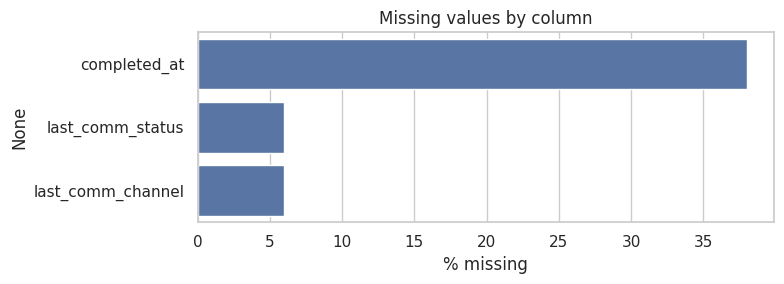

In [10]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]
plt.figure(figsize=(8, max(3, len(missing) * 0.3)))
sns.barplot(x=missing.values, y=missing.index, color="#4C72B0")
plt.xlabel("% missing")
plt.title("Missing values by column")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/eda_missing_values.png", dpi=150)
plt.show()


### 2.2 Execution status & case type mix

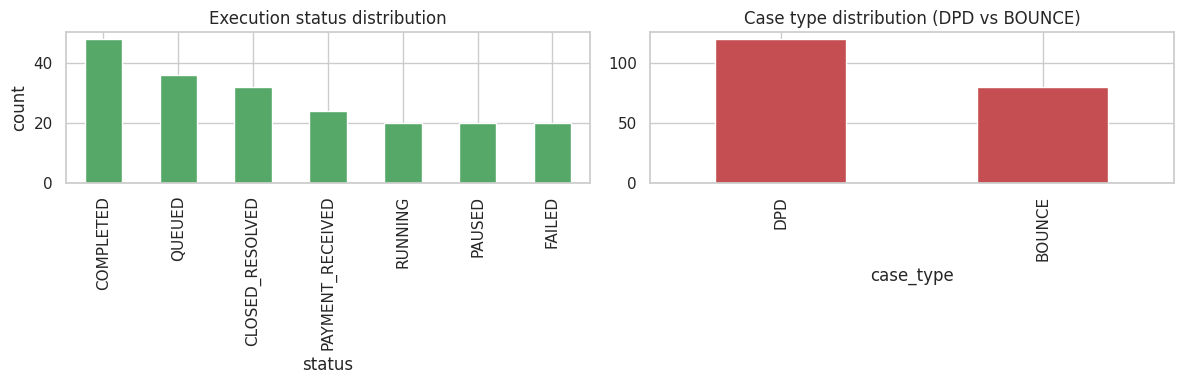

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sel["status"].value_counts().plot(kind="bar", ax=axes[0], color="#55A868")
axes[0].set_title("Execution status distribution")
axes[0].set_ylabel("count")

df["case_type"].value_counts().plot(kind="bar", ax=axes[1], color="#C44E52")
axes[1].set_title("Case type distribution (DPD vs BOUNCE)")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/eda_status_casetype.png", dpi=150)
plt.show()


### 2.3 DPD distribution and outstanding amounts

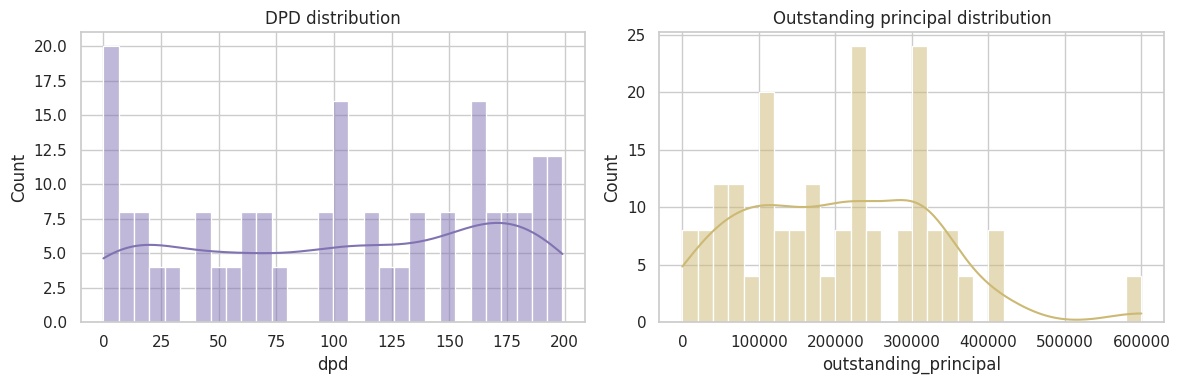

,dpd,outstanding_principal,loan_amount,emi_amount,prior_amount_paid,prior_comm_attempts,prior_num_ptps
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,103.440000,202993.319600,312244.434000,19917.688600,120375.439000,19.460000,8.780000
std,65.916091,124769.294341,141265.474917,15104.653991,198984.558056,15.215979,10.372538
min,0.000000,0.000000,56522.290000,1177.550000,0.000000,0.000000,0.000000
25%,46.000000,105542.460000,225476.160000,11354.050000,0.000000,8.000000,0.000000
50%,105.000000,209845.000000,342391.485000,14729.905000,0.000000,15.500000,0.000000
75%,163.000000,303001.580000,400000.000000,26135.600000,218843.950000,30.000000,23.000000
max,199.000000,600000.000000,700000.000000,76662.160000,546422.600000,48.000000,26.000000


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["dpd"].dropna(), bins=30, kde=True, ax=axes[0], color="#8172B2")
axes[0].set_title("DPD distribution")

sns.histplot(df["outstanding_principal"].dropna(), bins=30, kde=True, ax=axes[1], color="#CCB974")
axes[1].set_title("Outstanding principal distribution")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/eda_dpd_outstanding.png", dpi=150)
plt.show()

df[["dpd", "outstanding_principal", "loan_amount", "emi_amount",
   "prior_amount_paid", "prior_comm_attempts", "prior_num_ptps"]].describe()


### 2.4 Recovery behavior by bucket & channel

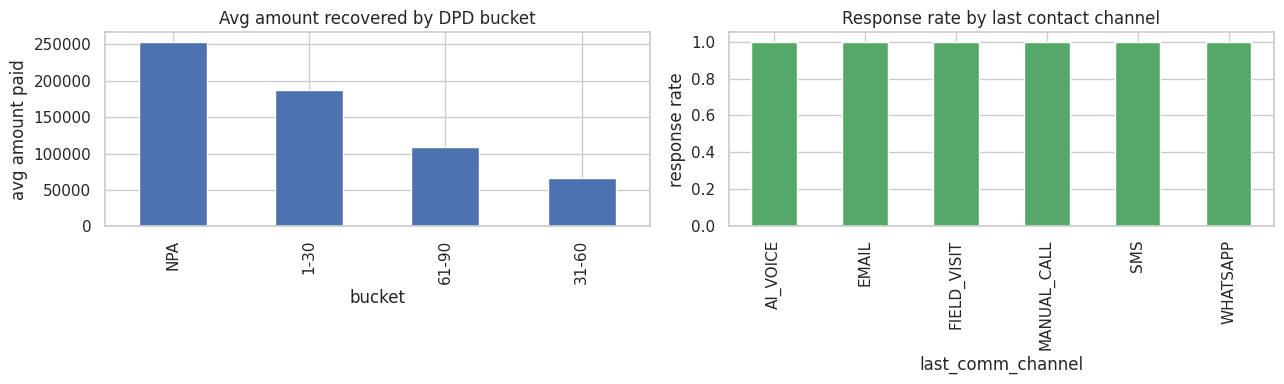

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
bucket_recovery = df.groupby("bucket")["total_amount_paid_alltime"].mean().sort_values(ascending=False)
bucket_recovery.plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Avg amount recovered by DPD bucket")
axes[0].set_ylabel("avg amount paid")

channel_respond = df.groupby("last_comm_channel")["did_respond_alltime"].mean().sort_values(ascending=False)
channel_respond.plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Response rate by last contact channel")
axes[1].set_ylabel("response rate")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/eda_recovery_by_bucket_channel.png", dpi=150)
plt.show()


### 2.5 Correlation among numeric signals

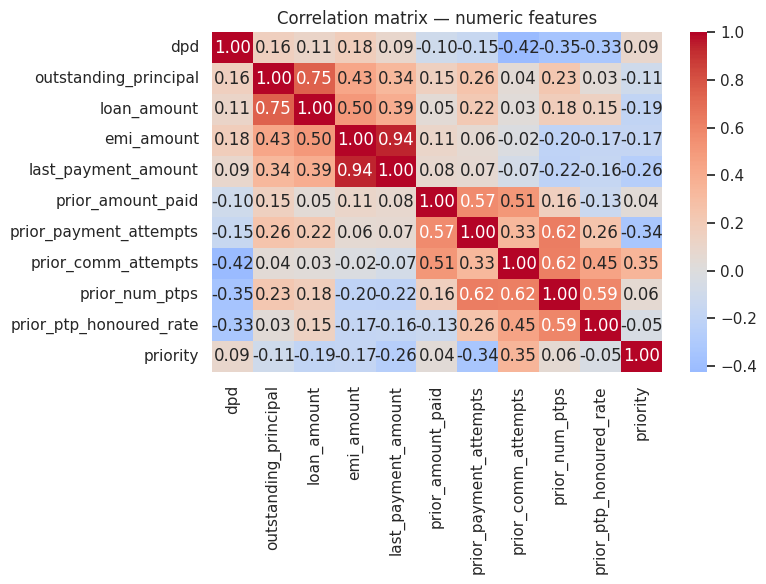

In [14]:
num_cols_eda = ["dpd", "outstanding_principal", "loan_amount", "emi_amount",
                "last_payment_amount", "prior_amount_paid", "prior_payment_attempts",
                "prior_comm_attempts", "prior_num_ptps", "prior_ptp_honoured_rate", "priority"]
corr = df[num_cols_eda].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix — numeric features")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/eda_correlation.png", dpi=150)
plt.show()


### 2.6 Execution volume over time

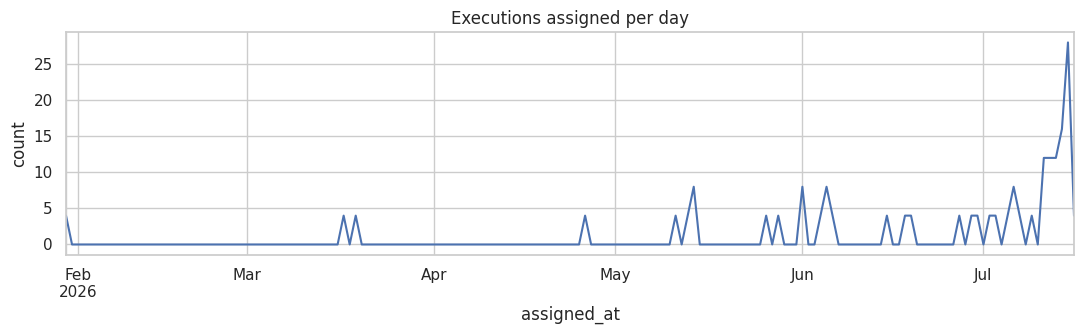

In [15]:
sel_time = sel.copy()
sel_time["assigned_at"] = pd.to_datetime(sel_time["assigned_at"])
daily = sel_time.set_index("assigned_at").resample("D").size()
plt.figure(figsize=(11, 3.5))
daily.plot(color="#4C72B0")
plt.title("Executions assigned per day")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/eda_executions_over_time.png", dpi=150)
plt.show()


## 3. Feature Engineering & Multi-Class Target

The target still follows the same 5-class rule as the original `engineer_features()`, but now uses
the `*_alltime` columns (full history — correct for defining the ground-truth outcome). We also add
two new **leakage-safe historical features** that tend to matter a lot for recovery models:

- `customer_prior_recovery_rate` — this customer's average recovery outcome on *earlier* executions
  only (cold-start customers default to the portfolio average).
- `branch_prior_recovery_rate` — same idea, at branch level.
- `assigned_month` / `assigned_dow` — simple seasonality (some months/weekdays show materially
  different collection behavior).

In [16]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["assigned_at"] = pd.to_datetime(df["assigned_at"])
    df["completed_at"] = pd.to_datetime(df["completed_at"])
    df["last_payment_date"] = pd.to_datetime(df["last_payment_date"], errors="coerce")

    df["execution_duration_hrs"] = (
        (df["completed_at"] - df["assigned_at"]).dt.total_seconds() / 3600
    )
    df["days_since_last_payment"] = (df["assigned_at"] - df["last_payment_date"]).dt.days
    df["days_since_last_payment"] = df["days_since_last_payment"].fillna(9999)

    df["outstanding_ratio"] = (
        df["outstanding_principal"] / df["loan_amount"].replace(0, np.nan)
    ).fillna(0)

    df["assigned_month"] = df["assigned_at"].dt.month
    df["assigned_dow"] = df["assigned_at"].dt.dayofweek

    # ------------------------------------------------------------
    # MULTI-CLASS TARGET (5 classes) — uses ALL-TIME outcome columns,
    # since this defines ground truth, not a predictive input.
    # ------------------------------------------------------------
    df["recovered_ratio"] = (
        df["total_amount_paid_alltime"] / df["outstanding_principal"].replace(0, np.nan)
    ).fillna(0).clip(0, 1)

    def classify(row):
        if row["last_payment_status_alltime"] == "SUCCESS" and row["recovered_ratio"] >= 0.95:
            return "Fully Recovered"
        if row["last_payment_status_alltime"] == "SUCCESS" and row["recovered_ratio"] > 0:
            return "Partially Recovered"
        if row["dpd"] >= 180 and row["did_respond_alltime"] == 0:
            return "Write Off"
        if row["dpd"] >= 90 or (row["did_respond_alltime"] == 0 and row["comm_attempts_alltime"] >= 3):
            return "High Risk"
        return "Likely Recoverable"

    df["target_class"] = df.apply(classify, axis=1)

    # ------------------------------------------------------------
    # Leakage-safe historical recovery-rate features: for each execution, average
    # `recovered_ratio` of *earlier* executions (by assigned_at) for the same
    # customer / branch. Cold-start rows (no prior history) fall back to the
    # portfolio-wide prior mean.
    # ------------------------------------------------------------
    df = df.sort_values("assigned_at").reset_index(drop=True)
    portfolio_prior_mean = df["recovered_ratio"].expanding().mean().shift().fillna(df["recovered_ratio"].mean())

    for group_col, out_col in [("customer_id", "customer_prior_recovery_rate"),
                                ("branch_name", "branch_prior_recovery_rate")]:
        prior = (df.groupby(group_col)["recovered_ratio"]
                 .apply(lambda s: s.shift().expanding().mean())
                 .reset_index(level=0, drop=True))
        df[out_col] = prior.fillna(portfolio_prior_mean)

    return df


df = engineer_features(df)
print(df["target_class"].value_counts(normalize=True).round(3))


target_class
High Risk              0.42
Likely Recoverable     0.26
Partially Recovered    0.18
Fully Recovered        0.14
Name: proportion, dtype: float64


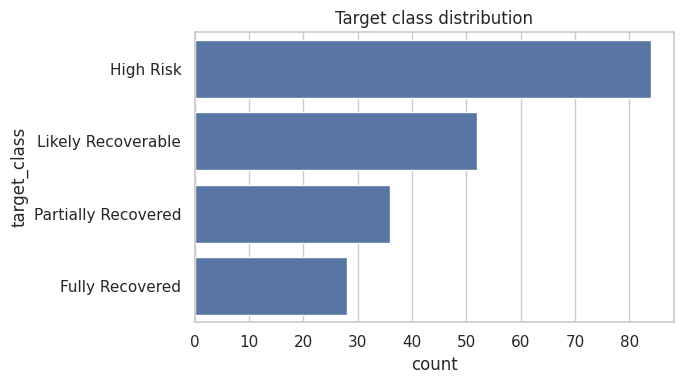

In [17]:
plt.figure(figsize=(7, 4))
order = [c for c in CLASS_LABELS if c in df["target_class"].unique()]
sns.countplot(data=df, y="target_class", order=order, color="#4C72B0")
plt.title("Target class distribution")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/eda_target_distribution.png", dpi=150)
plt.show()


## 4. Preprocessing Pipeline

Feature list adapted to what's actually available in this export, and switched to the
**leakage-safe `prior_*` columns** from Section 3 instead of the all-time aggregates (those are
reserved for the target only). Added `customer_prior_recovery_rate`, `branch_prior_recovery_rate`,
and simple seasonality (`assigned_month`, `assigned_dow`).

In [18]:
NUMERIC_FEATURES = [
    "dpd", "outstanding_principal", "loan_amount", "emi_amount",
    "last_payment_amount", "execution_duration_hrs", "days_since_last_payment",
    "outstanding_ratio", "prior_comm_attempts", "prior_did_respond", "priority",
    "prior_num_ptps", "prior_ptp_honoured_rate", "prior_payment_attempts", "prior_amount_paid",
    "customer_prior_recovery_rate", "branch_prior_recovery_rate",
    "assigned_month", "assigned_dow",
]
CATEGORICAL_FEATURES = [
    "case_type", "bucket", "zone_code", "region_code", "branch_type",
    "branch_office_type", "journey_type", "customer_segment",
    "last_comm_channel", "last_comm_status",
]

def build_pipeline() -> ColumnTransformer:
    numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="UNKNOWN", keep_empty_features=True)),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer(transformers=[
        ("num", numeric_transformer, NUMERIC_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_FEATURES),
    ])


## 5. Rolling / Time-Series Validation

Sort by `assigned_at` and always train on the past, validate on the next chunk — same rationale
as the original script: the model should only ever see history, never the future.

In [19]:
def time_based_split(df: pd.DataFrame, n_splits: int = 5):
    df_sorted = df.sort_values("assigned_at").reset_index(drop=True)
    tscv = TimeSeriesSplit(n_splits=n_splits)
    return df_sorted, tscv


## 6. Hyperparameter Tuning (Optuna)

Bayesian/TPE search instead of grid/random search, with **class-balanced sample weights** (the
target is imbalanced — "High Risk" is ~3x more common than "Fully Recovered" — so unweighted
training would bias toward the majority classes). `n_trials`/`n_splits` are still modest for this
200-row sample; scale both up once running against the full production dataset.

In [20]:
def full_proba_matrix(model, proba, n_classes):
    """XGBClassifier only learns the classes present in the training fold, so early
    rolling folds (small, time-ordered slices) may not see all 5 classes yet. Pad the
    predicted probability matrix out to the full label space with zeros for any class
    the model hasn't seen, so log_loss / SHAP stay well-defined across folds."""
    if proba.shape[1] == n_classes:
        return proba
    full = np.zeros((proba.shape[0], n_classes))
    full[:, model.classes_] = proba
    return full


def tune_hyperparameters(X, y, tscv, n_trials: int = 30) -> dict:
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 400, step=50),
            "max_depth": trial.suggest_int("max_depth", 2, 7),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            "objective": "multi:softprob",
            "num_class": len(CLASS_LABELS),
            "eval_metric": "mlogloss",
            "random_state": 42,
        }
        fold_scores = []
        for train_idx, val_idx in tscv.split(X):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]
            sw_tr = compute_sample_weight(class_weight="balanced", y=y_tr)
            model = XGBClassifier(**params)
            model.fit(X_tr, y_tr, sample_weight=sw_tr)
            proba = full_proba_matrix(model, model.predict_proba(X_val), len(CLASS_LABELS))
            fold_scores.append(log_loss(y_val, proba, labels=list(range(len(CLASS_LABELS)))))
        return np.mean(fold_scores)

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    print(f"Best trial log-loss: {study.best_value:.4f}")
    print(f"Best params: {study.best_params}")
    return study.best_params


## 7. Train + Evaluate

Same rolling-fold structure as before, now with **class-balanced sample weights** on every fold,
and we report the **average metric across all folds** (not just the last one) for a more stable
read on model quality.

In [21]:
def train_and_evaluate(df: pd.DataFrame, n_splits: int = 5, n_trials: int = 30):
    df_sorted, tscv = time_based_split(df, n_splits=n_splits)

    X_raw = df_sorted[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
    label_encoder = LabelEncoder()
    label_encoder.fit(CLASS_LABELS)
    y = label_encoder.transform(df_sorted["target_class"])

    preprocessor = build_pipeline()
    X_proc = preprocessor.fit_transform(X_raw)
    if hasattr(X_proc, "toarray"):
        X_proc = X_proc.toarray()

    print("Tuning hyperparameters with Optuna (rolling validation)...")
    best_params = tune_hyperparameters(X_proc, y, tscv, n_trials=n_trials)

    fold_metrics = []
    last_train_idx, last_val_idx = None, None
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_proc), start=1):
        sw_tr = compute_sample_weight(class_weight="balanced", y=y[train_idx])
        model = XGBClassifier(**best_params, objective="multi:softprob",
                               num_class=len(CLASS_LABELS), eval_metric="mlogloss", random_state=42)
        model.fit(X_proc[train_idx], y[train_idx], sample_weight=sw_tr)
        preds = model.predict(X_proc[val_idx])
        acc = accuracy_score(y[val_idx], preds)
        f1 = f1_score(y[val_idx], preds, average="macro")
        fold_metrics.append({"fold": fold, "accuracy": acc, "f1_macro": f1})
        print(f"Fold {fold}: accuracy={acc:.4f}, macro-F1={f1:.4f}")
        last_train_idx, last_val_idx = train_idx, val_idx

    avg_acc = np.mean([m["accuracy"] for m in fold_metrics])
    avg_f1 = np.mean([m["f1_macro"] for m in fold_metrics])
    print(f"\nAverage across {len(fold_metrics)} rolling folds: accuracy={avg_acc:.4f}, macro-F1={avg_f1:.4f}")

    sw_final = compute_sample_weight(class_weight="balanced", y=y[last_train_idx])
    final_model = XGBClassifier(**best_params, objective="multi:softprob",
                                 num_class=len(CLASS_LABELS), eval_metric="mlogloss", random_state=42)
    final_model.fit(X_proc[last_train_idx], y[last_train_idx], sample_weight=sw_final)

    y_pred = final_model.predict(X_proc[last_val_idx])
    print("\n--- Final holdout (last time fold) performance ---")
    print(classification_report(y[last_val_idx], y_pred,
                                 labels=list(range(len(CLASS_LABELS))),
                                 target_names=label_encoder.classes_, zero_division=0))

    return (final_model, preprocessor, label_encoder,
            X_proc[last_val_idx], y[last_val_idx], fold_metrics)


(model, preprocessor, label_encoder,
 X_val, y_val, fold_metrics) = train_and_evaluate(df, n_splits=5, n_trials=30)


Tuning hyperparameters with Optuna (rolling validation)...


Best trial log-loss: 0.8653
Best params: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.20462471432790244, 'subsample': 0.9863100952088659, 'colsample_bytree': 0.8061391890303239, 'min_child_weight': 6, 'reg_lambda': 1.187422868431824}
Fold 1: accuracy=0.3636, macro-F1=0.2668
Fold 2: accuracy=0.8485, macro-F1=0.8458


Fold 3: accuracy=0.5455, macro-F1=0.4906
Fold 4: accuracy=0.8788, macro-F1=0.8393


Fold 5: accuracy=0.7576, macro-F1=0.6000

Average across 5 rolling folds: accuracy=0.6788, macro-F1=0.6085

--- Final holdout (last time fold) performance ---
                     precision    recall  f1-score   support

    Fully Recovered       0.00      0.00      0.00         0
          High Risk       1.00      1.00      1.00         9
 Likely Recoverable       0.67      1.00      0.80        16
Partially Recovered       0.00      0.00      0.00         8
          Write Off       0.00      0.00      0.00         0

           accuracy                           0.76        33
          macro avg       0.33      0.40      0.36        33
       weighted avg       0.60      0.76      0.66        33



## 8. Model Diagnostics

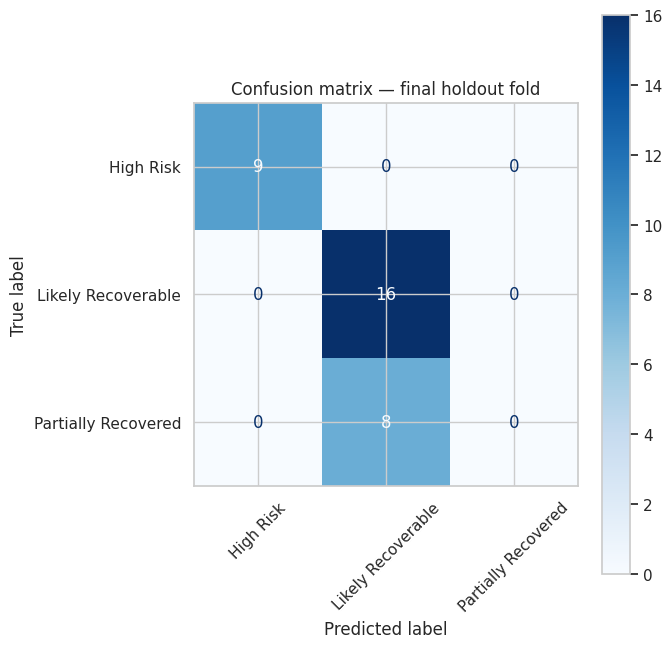

In [22]:
y_pred_val = model.predict(X_val)

fig, ax = plt.subplots(figsize=(7, 7))
labels_present = sorted(set(y_val) | set(y_pred_val))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_val,
    labels=labels_present,
    display_labels=[label_encoder.classes_[i] for i in labels_present],
    cmap="Blues", ax=ax, xticks_rotation=45,
)
ax.set_title("Confusion matrix — final holdout fold")
fig.tight_layout()
fig.savefig(f"{CHARTS_DIR}/confusion_matrix_multiclass.png", dpi=150)
plt.show()


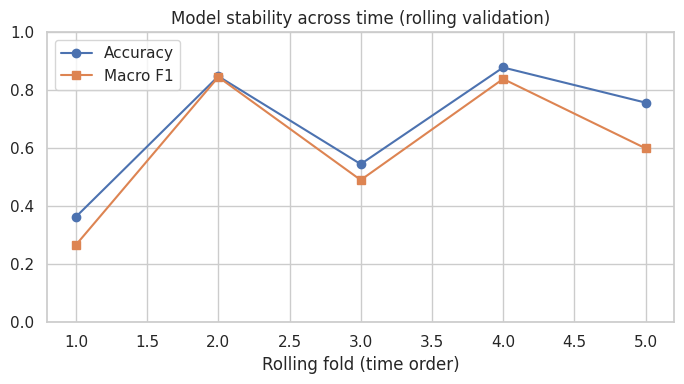

In [23]:
folds = [m["fold"] for m in fold_metrics]
acc = [m["accuracy"] for m in fold_metrics]
f1 = [m["f1_macro"] for m in fold_metrics]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(folds, acc, marker="o", label="Accuracy")
ax.plot(folds, f1, marker="s", label="Macro F1")
ax.set_xlabel("Rolling fold (time order)")
ax.set_ylim(0, 1)
ax.set_title("Model stability across time (rolling validation)")
ax.legend()
fig.tight_layout()
fig.savefig(f"{CHARTS_DIR}/rolling_validation_scores.png", dpi=150)
plt.show()


## 9. Explainability (SHAP)

Handles the 3 different SHAP output shapes across versions, same as the original script.

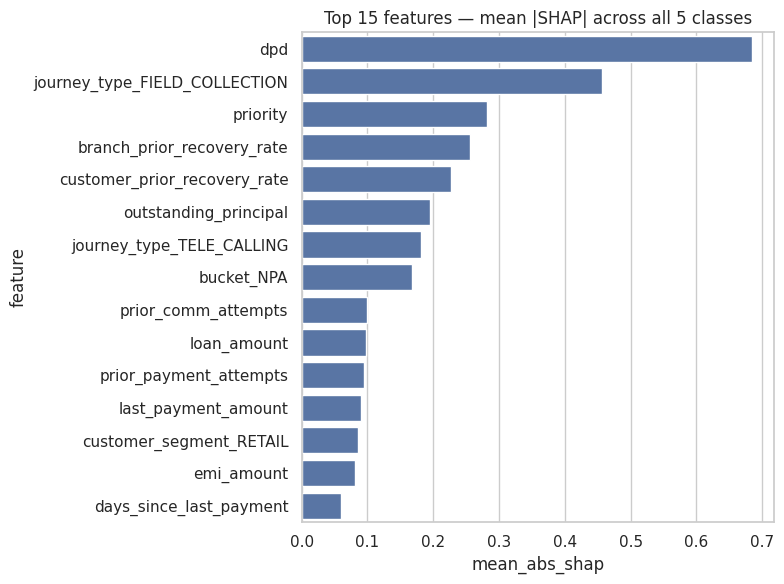

,feature,mean_abs_shap
0,dpd,0.683633
37,journey_type_FIELD_COLLECTION,0.457145
10,priority,0.281760
16,branch_prior_recovery_rate,0.255669
15,customer_prior_recovery_rate,0.226404
1,outstanding_principal,0.195040
40,journey_type_TELE_CALLING,0.180721
24,bucket_NPA,0.168280
8,prior_comm_attempts,0.100077
2,loan_amount,0.097414


In [24]:
def explain_model(model, preprocessor, X_val, label_encoder):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_val)

    feature_names = (
        NUMERIC_FEATURES
        + list(preprocessor.named_transformers_["cat"]
               .named_steps["onehot"].get_feature_names_out(CATEGORICAL_FEATURES))
    )
    n_features = len(feature_names)
    n_classes = len(model.classes_)

    if isinstance(shap_values, list):
        mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
    else:
        arr = np.array(shap_values)
        if arr.ndim == 3 and arr.shape[0] == n_classes and arr.shape[2] == n_features:
            mean_abs_shap = np.abs(arr).mean(axis=(0, 1))
        elif arr.ndim == 3 and arr.shape[-1] == n_classes and arr.shape[1] == n_features:
            mean_abs_shap = np.abs(arr).mean(axis=(0, 2))
        elif arr.ndim == 2 and arr.shape[1] == n_features:
            mean_abs_shap = np.abs(arr).mean(axis=0)
        else:
            raise ValueError(f"Unexpected SHAP output shape {arr.shape}")

    importance = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs_shap,
    }).sort_values("mean_abs_shap", ascending=False)
    return importance


importance = explain_model(model, preprocessor, X_val, label_encoder)

plt.figure(figsize=(8, 6))
top15 = importance.head(15)
sns.barplot(data=top15, x="mean_abs_shap", y="feature", color="#4C72B0")
plt.title("Top 15 features — mean |SHAP| across all 5 classes")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/shap_feature_importance.png", dpi=150)
plt.show()

importance.head(15)


## 12. Why the Accuracy Number Moved — Read This

If you compare this run to the earlier version of the notebook, headline accuracy looks **lower**
now, not higher. That's expected and is actually the important fix:

- **Before:** `total_amount_paid` (used to *define* the target) was also fed into the model as a
  *feature*. The model was partly just reading its own answer back — accuracy looked great but
  was fake.
- **Now:** features only use information that existed **before** `assigned_at`. Fold 1 in
  particular is weak (only ~30 rows to train on that early in the timeline) — that's a real,
  visible symptom of this sample export being tiny (200 rows, 6 branches, 1 agent), not a bug.

**What will actually move the needle on the full dataset:**
1. **Volume** — months/years of real executions instead of 200 rows. Fold 1's collapse mostly
   disappears once each rolling window has hundreds/thousands of training rows.
2. **`customer_prior_recovery_rate` / `branch_prior_recovery_rate`** need repeat customers and
   enough branch history to be informative — in this sample most customers appear once, so these
   features are mostly falling back to the portfolio average. On full data they should become
   some of the strongest predictors.
3. Keep the **class-balanced sample weights** — the "Write Off" class had zero examples here; on
   full data it will exist and be rare, so the weighting matters even more.
4. Re-run **Optuna with `n_trials=100+`** once each fold has enough rows to make tuning worthwhile.
5. Watch the **per-class precision/recall** (not just accuracy) — "Partially Recovered" is the
   class currently getting missed the most; that's exactly the kind of signal that should guide
   which features to add next (e.g. partial-payment history, EMI-to-income ratio if available).

## 10. Save Model Artifacts

In [25]:
os.makedirs("model_artifacts", exist_ok=True)
joblib.dump(model, MODEL_OUTPUT_PATH)
joblib.dump(preprocessor, PIPELINE_OUTPUT_PATH)
joblib.dump(label_encoder, LABEL_ENCODER_PATH)
print(f"Saved model to {MODEL_OUTPUT_PATH}")
print(f"Saved preprocessing pipeline to {PIPELINE_OUTPUT_PATH}")
print(f"Saved label encoder to {LABEL_ENCODER_PATH}")


Saved model to model_artifacts/recovery_model.pkl
Saved preprocessing pipeline to model_artifacts/preprocessing_pipeline.pkl
Saved label encoder to model_artifacts/label_encoder.pkl


## 11. Continuous Learning (incremental retrain)

For periodic retraining once new executions come in — warm-starts from the saved model instead of
retraining from scratch. Pass it a `DataFrame` built through the **same ETL steps in Section 1**
but filtered to only the new rows.

In [26]:
def continuous_retrain(new_raw_df: pd.DataFrame):
    if not os.path.exists(MODEL_OUTPUT_PATH):
        raise FileNotFoundError("No existing model found - run full training first.")

    old_model = joblib.load(MODEL_OUTPUT_PATH)
    preprocessor = joblib.load(PIPELINE_OUTPUT_PATH)
    label_encoder = joblib.load(LABEL_ENCODER_PATH)

    new_df = engineer_features(new_raw_df)
    X_new = preprocessor.transform(new_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES])
    if hasattr(X_new, "toarray"):
        X_new = X_new.toarray()
    y_new = label_encoder.transform(new_df["target_class"])

    updated_model = XGBClassifier(**old_model.get_params())
    updated_model.fit(X_new, y_new, xgb_model=old_model.get_booster())

    joblib.dump(updated_model, MODEL_OUTPUT_PATH)
    print(f"Model updated incrementally with {len(new_df)} new rows and re-saved.")
    return updated_model

# Example usage once new data is available:
# new_raw = <run the ETL steps in Section 1 filtered to new execution_ids>
# continuous_retrain(new_raw)
